# Chain Model Evaluation - US Traffic Incident Analysis
ในขั้นตอนนี้เราจะนำ Model ทั้งสองตัวที่ Train ไว้มาทดสอบกับ Test Set โดยใช้กระบวนการแบบ Chain:
1. ใช้ **Model 1** ทำนาย `Distance(mi)` จาก Features พื้นฐาน
2. นำ `Distance(mi)` ที่ทำนายได้ ไปรวมกับ Features พื้นฐาน
3. ใช้ **Model 2** ทำนาย `Duration(min)`
4. วัดผลลัพธ์สุดท้ายเปรียบเทียบกับคำตอบจริง (Ground Truth)

In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 1. Load Test Data & Models

In [2]:
# โหลด Features ของ Test Set
X_test = pd.read_csv("../data/processed/03/test_features.csv")

# โหลดคำตอบจริง (Ground Truth)
y_true = pd.read_csv("../data/processed/01.2/test_secret_answers.csv")

# โหลด Models
model_dist = joblib.load("../models/chain_dist_model.pkl")
model_dur = joblib.load("../models/chain_dur_model.pkl")

print(f"X_test shape: {X_test.shape}")
print(f"y_true shape: {y_true.shape}")

X_test shape: (1367273, 59)
y_true shape: (1367273, 2)


## 2. Step 1: Predict Distance
ใช้ Model 1 ทำนายระยะทาง

In [3]:
print("Predicting Distance...")
pred_distance = model_dist.predict(X_test)

# ตรวจสอบผลลัพธ์ของ Model 1
dist_mae = mean_absolute_error(y_true["Distance(mi)"], pred_distance)
print(f"Distance Prediction MAE: {dist_mae:.4f} miles")

Predicting Distance...
Distance Prediction MAE: 0.5039 miles


## 3. Step 2: Predict Duration using Predicted Distance
นำผลลัพธ์จาก Step 1 มาเป็น Feature ให้ Model 2

In [4]:
X_test_with_pred_dist = X_test.copy()
X_test_with_pred_dist["Distance(mi)"] = pred_distance

print("Predicting Duration (Chain Strategy)...")
pred_duration_chain = model_dur.predict(X_test_with_pred_dist)

# --- Oracle Test (เพื่อดูว่าถ้าทำนายระยะทางเป๊ะ ผลลัพธ์จะเป็นอย่างไร) ---
X_test_with_true_dist = X_test.copy()
X_test_with_true_dist["Distance(mi)"] = y_true["Distance(mi)"]
pred_duration_oracle = model_dur.predict(X_test_with_true_dist)

print("Evaluation complete!")

Predicting Duration (Chain Strategy)...
Evaluation complete!


## 4. Result Comparison Table
ตารางเปรียบเทียบผลลัพธ์แบบรายแถวเพื่อให้เห็นภาพชัดเจน

In [5]:
results_df = pd.DataFrame({
    'Actual_Distance': y_true['Distance(mi)'],
    'Pred_Distance': pred_distance,
    'Actual_Duration': y_true['Duration(min)'],
    'Pred_Duration': pred_duration_chain,
    'Error_Duration': np.abs(y_true['Duration(min)'] - pred_duration_chain)
})

print("\n--- First 10 Predictions Comparison ---")
display(results_df)


--- First 10 Predictions Comparison ---


,Actual_Distance,Pred_Distance,Actual_Duration,Pred_Duration,Error_Duration
0,0.344,0.470082,128.750000,4.718280,124.031720
1,0.000,0.898683,28.916667,4.819901,24.096766
2,0.000,0.152532,47.633333,4.766777,42.866556
3,0.000,0.051015,91.633333,4.000749,87.632584
4,0.000,0.229260,43.916667,4.227548,39.689119
...,...,...,...,...,...
1367268,0.718,0.458549,360.000000,5.079567,354.920433
1367269,0.000,0.186776,59.866667,4.482256,55.384410
1367270,0.000,0.365845,28.583333,4.567596,24.015737
1367271,0.127,0.267107,127.966667,4.974047,122.992620


## 5. Performance Metrics & Gap Analysis
เปรียบเทียบว่าการใช้ Distance ที่ทำนายมา (Chain) เทียบกับ Distance จริง (Oracle) ทำให้ประสิทธิภาพลดลงแค่ไหน

In [6]:
def calculate_metrics(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2': r2_score(y_true, y_pred)
    }

chain_metrics = calculate_metrics(y_true["Duration(min)"], pred_duration_chain)
oracle_metrics = calculate_metrics(y_true["Duration(min)"], pred_duration_oracle)

metrics_comparison = pd.DataFrame({
    'Chain Model (Pred Dist)': chain_metrics,
    'Oracle Model (True Dist)': oracle_metrics
}).T

print("\n--- Metrics Comparison ---")
display(metrics_comparison)

print(f"\nPerformance Gap (MAE): {chain_metrics['MAE'] - oracle_metrics['MAE']:.4f} minutes")


--- Metrics Comparison ---


,MAE,RMSE,R2
Chain Model (Pred Dist),112.343688,267.478194,-0.213482
Oracle Model (True Dist),112.614982,267.502936,-0.213706



Performance Gap (MAE): -0.2713 minutes


## 6. Visualization

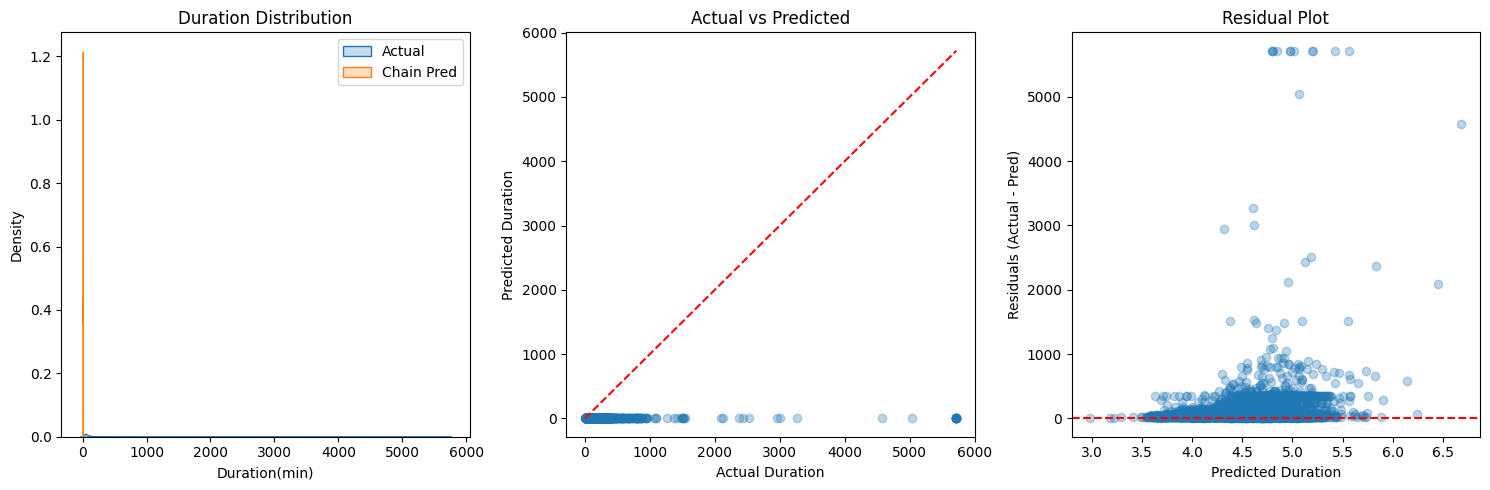

In [7]:
plt.figure(figsize=(15, 5))

# 1. Distribution Plot
plt.subplot(1, 3, 1)
sns.kdeplot(y_true["Duration(min)"], label='Actual', fill=True)
sns.kdeplot(pred_duration_chain, label='Chain Pred', fill=True)
plt.title("Duration Distribution")
plt.legend()

# 2. Scatter Plot (Actual vs Pred)
plt.subplot(1, 3, 2)
sample_idx = np.random.choice(len(y_true), 5000, replace=False)
plt.scatter(y_true["Duration(min)"].iloc[sample_idx], pred_duration_chain[sample_idx], alpha=0.3)
plt.plot([y_true["Duration(min)"].min(), y_true["Duration(min)"].max()], 
         [y_true["Duration(min)"].min(), y_true["Duration(min)"].max()], 'r--')
plt.xlabel("Actual Duration")
plt.ylabel("Predicted Duration")
plt.title("Actual vs Predicted")

# 3. Residual Plot
plt.subplot(1, 3, 3)
residuals = y_true["Duration(min)"] - pred_duration_chain
plt.scatter(pred_duration_chain[sample_idx], residuals.iloc[sample_idx], alpha=0.3)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted Duration")
plt.ylabel("Residuals (Actual - Pred)")
plt.title("Residual Plot")

plt.tight_layout()
plt.show()